<a href="https://colab.research.google.com/github/239y1a3931-sudo/Machain-Learning/blob/main/day10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GINI

In [ ]:
#importing libraries
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [ ]:
#Gini cal
def gini_impurity(labels):
  labels=np.array(labels)
  n=len(labels)
  if n==0: return 0
  clas= np.unique(labels)
  gini=1.0
  for c in clas:
    p=np.sum(labels==c)/n #if labels and unique c are same divide by n(len_labels)
    gini-= p**2 # gini = p(square)
  return gini

In [ ]:
# Test different node compositions
print('Pure node (all same) :', gini_impurity([1,1,1,1,1])) # 0.00
print('50-50 split :', gini_impurity([0,0,0,1,1,1])) # 0.50
print('70-30 split :', gini_impurity([0,0,0,0,0,0,0,1,1,1])) # 0.42
print('90-10 split :', gini_impurity([0]*9 + [1])) # 0.18
print('left_labels:',gini_impurity([0,0,0,0,1]))
print('right_labels:',gini_impurity([0,1,1,1,1]))

Pure node (all same) : 0.0
50-50 split : 0.5
70-30 split : 0.42000000000000004
90-10 split : 0.17999999999999994
left_labels: 0.31999999999999984
right_labels: 0.31999999999999984


In [ ]:
def weight_labels(left_label,right_label):
  n_total=len(left_label)+len(right_label)
  weight_left=len(left_label)/n_total
  weight_right=len(right_label)/n_total
  return weight_left*gini_impurity(left_label)+weight_right*gini_impurity(right_label)

In [ ]:
print('weighted_gini:',weight_labels([0,0,0,0,1],[1,1,1,1,0]))

weighted_gini: 0.31999999999999984


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [ ]:
X,y=make_classification(n_samples=10000,n_features=50,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
depths=range(1,11)

In [ ]:
train_acc,test_acc=[],[]

In [ ]:
for d in depths:
  tree=DecisionTreeClassifier(max_depth=d,random_state=42)
  tree.fit(X_train,y_train)
  train_acc.append(accuracy_score(y_train,tree.predict(X_train)))
  test_acc.append(accuracy_score(y_test,tree.predict(X_test)))

In [ ]:
best_depth=depths[test_acc.index(max(test_acc))]

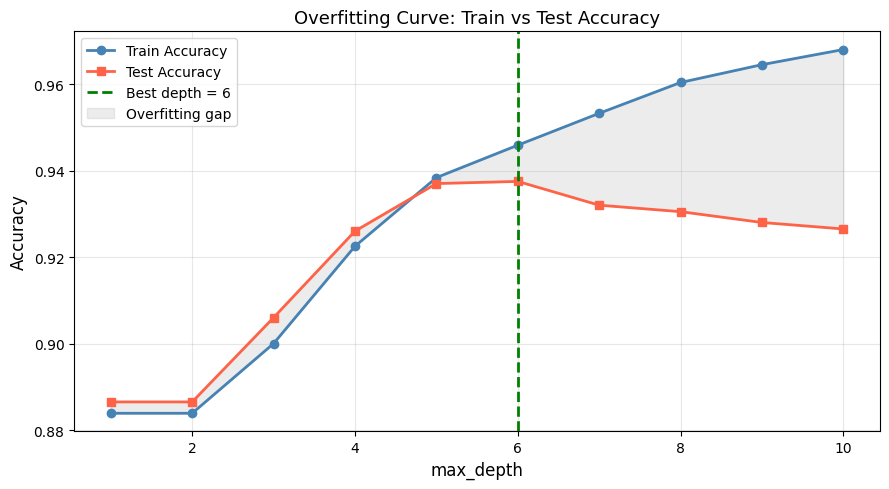

Best test accuracy 93.75% at depth=6


In [ ]:
#graph
plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, 'o-', color='steelblue', lw=2, label='Train Accuracy')
plt.plot(depths, test_acc, 's-', color='tomato', lw=2, label='Test Accuracy')
plt.axvline(x=best_depth, color='green', linestyle='--', lw=2,
            label=f'Best depth = {best_depth}')
plt.fill_between(depths,
                 train_acc, test_acc,
                 alpha=0.15, color='gray', label='Overfitting gap')
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Overfitting Curve: Train vs Test Accuracy', fontsize=13)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'Best test accuracy {max(test_acc):.2%} at depth={best_depth}')

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
configs = [
{'max_depth': None}, # Unrestricted (likely overfit)
{'max_depth': 5}, # Limit depth
{'max_depth': 5, 'min_samples_split': 10}, # Split only if 10+ samples
{'max_depth': 5, 'min_samples_leaf': 5}, # Each leaf needs 5+ samples
{'max_depth': 5, 'max_features': 'sqrt'}, # Only consider sqrt(n_features) per split
]

print(f'{'Config':45s} {'CV Score (mean±std)':20s}')
print('-' * 60)


Config                                        CV Score (mean±std) 
------------------------------------------------------------


In [ ]:
for cfg in configs:
  tree = DecisionTreeClassifier(**cfg, random_state=42)
  scores = cross_val_score(tree, X, y, cv=7, scoring='accuracy')
  print(f'{str(cfg):45s} {scores.mean():.3f} ± {scores.std():.3f}')

{'max_depth': None}                           0.888 ± 0.009
{'max_depth': 5}                              0.929 ± 0.009
{'max_depth': 5, 'min_samples_split': 10}     0.929 ± 0.009
{'max_depth': 5, 'min_samples_leaf': 5}       0.929 ± 0.008
{'max_depth': 5, 'max_features': 'sqrt'}      0.859 ± 0.014
